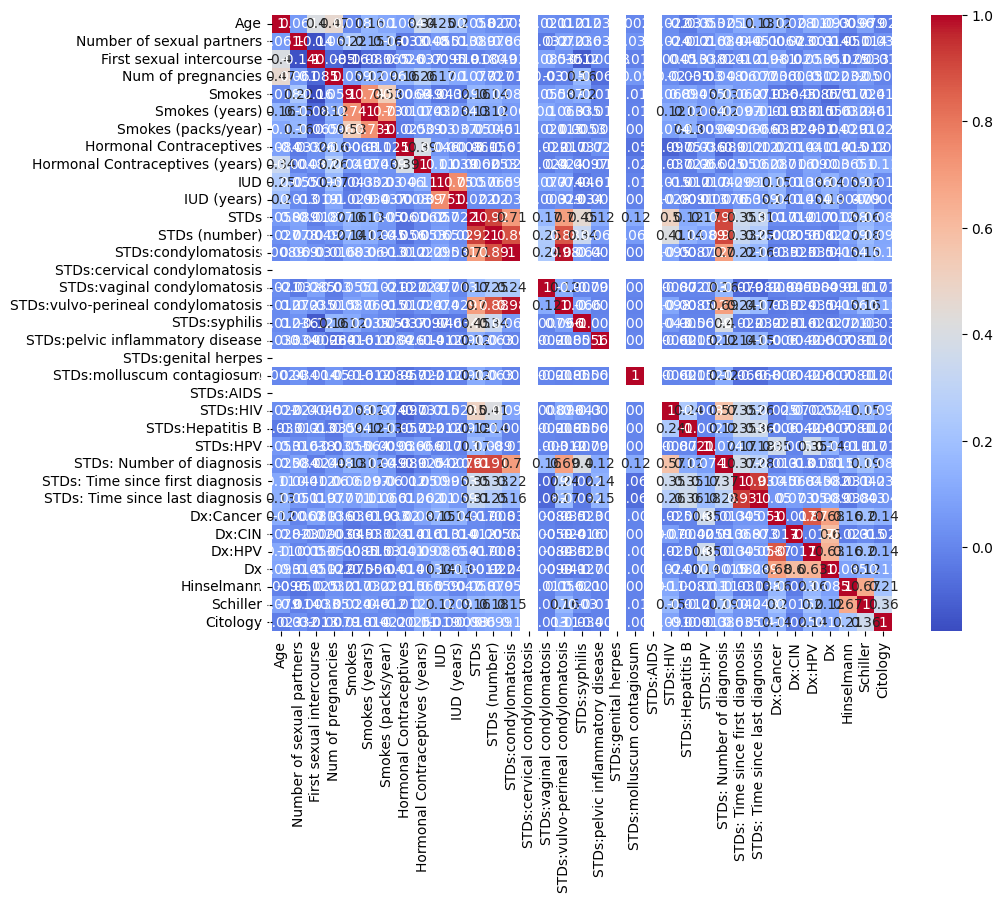

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import seaborn as sns

import matplotlib.pyplot as plt

# Assuming df is your dataframe loaded previously, e.g., df = pd.read_csv('your_data.csv')
# 1. Définition de la cible (assuming 'target' is the target column)
target = 'target'  # Replace with your actual target column name
df = pd.read_csv('data.csv')  # Replace with your actual data file path
X = df.drop(columns=['Biopsy'])
y = df['Biopsy']

# 2. Division en 80% entraînement et 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Retrait des colonnes avec >= 60% de valeurs manquantes
missing_threshold = 0.6
X_train = X_train.loc[:, X_train.isnull().mean() < missing_threshold]
X_test = X_test[X_train.columns]  # Ensure test has same columns

# 4. Retrait des lignes avec >= 60% de valeurs manquantes
X_train = X_train.loc[X_train.isnull().mean(axis=1) < missing_threshold]
y_train = y_train.loc[X_train.index]
X_test = X_test.loc[X_test.isnull().mean(axis=1) < missing_threshold]
y_test = y_test.loc[X_test.index]

# 5. Détection et suppression des valeurs aberrantes (IQR) - CORRIGÉ
def remove_outliers_iqr(df):
    for col in df.select_dtypes(include=[np.number]).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR > 0:  # Only filter if IQR > 0 to avoid removing 1s in binary columns
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

X_train = remove_outliers_iqr(X_train)
y_train = y_train.loc[X_train.index]

# 6. Remplacement des valeurs manquantes par la médiane
X_train = X_train.replace('?', np.nan).apply(pd.to_numeric, errors='coerce')
X_train = X_train.fillna(X_train.median())
X_test = X_test.replace('?', np.nan).apply(pd.to_numeric, errors='coerce')
X_test = X_test.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())  # Use train median for test

# 7. Matrice de corrélation
corr_matrix = X_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

# 8. Gestion du déséquilibre avec SMOTE - SÉCURISÉ
min_class_samples = y_train.value_counts().min()
k_neighbors = min(5, min_class_samples - 1)  # Ensure k_neighbors <= min_class_samples - 1
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 9. Normalisation des valeurs
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Now X_train_scaled, X_test_scaled, y_train_sm, y_test are ready for modeling
# ...existing code...
# Après la normalisation
import os
import pandas as pd

# Chemin du dossier
output_dir = '../data'

# Crée le dossier si nécessaire
os.makedirs(output_dir, exist_ok=True)

# Maintenant tu peux sauvegarder tes fichiers
pd.DataFrame(X_train_scaled).to_csv(f'{output_dir}/X_train_cleaned.csv', index=False)
pd.DataFrame(X_test_scaled).to_csv(f'{output_dir}/X_test_cleaned.csv', index=False)
y_train_sm.to_csv(f'{output_dir}/y_train_cleaned.csv', index=False)
# ...existing code...

In [4]:
import os
import pandas as pd

# vérifier que le fichier est bien là et charger les données

# default to the actual location of the dataset within the project
file_path = 'data/processed_data.csv'
if not os.path.isfile(file_path):
    # try simpler name as well
    file_path = 'data.csv'

if not os.path.isfile(file_path):
    print(f"Le fichier {file_path} n'existe pas dans le répertoire courant.")
    print(f"Répertoire courant : {os.getcwd()}")
    print("Fichiers disponibles :", os.listdir('.'))
    # Try to find the file in common locations
    possible_paths = [
        'data/processed_data.csv',
        'data.csv',
        '../data/processed_data.csv',
        '../data.csv',
        '../../data/processed_data.csv',
        '../../data.csv',
    ]
    
    file_found = False
    for path in possible_paths:
        if os.path.isfile(path):
            file_path = path
            file_found = True
            print(f"Fichier trouvé à : {path}")
            break
    
    if not file_found:
        raise FileNotFoundError(f"Le fichier {file_path} est introuvable. Vérifiez le chemin d'accès.")
df = pd.read_csv(file_path)

# s'assurer que la colonne cible existe
if target not in df.columns:
    target = 'target'

print("Dimensions du DataFrame :", df.shape)
print(df.head())

# redéfinir X et y pour la suite du traitement
target = 'Biopsy'  # or 'Dx:Cancer', 'Hinselmann', etc.
X = df.drop(columns=[target])
y = df[target]

Dimensions du DataFrame : (858, 36)
   Age Number of sexual partners First sexual intercourse Num of pregnancies  \
0   18                       4.0                     15.0                1.0   
1   15                       1.0                     14.0                1.0   
2   34                       1.0                        ?                1.0   
3   52                       5.0                     16.0                4.0   
4   46                       3.0                     21.0                4.0   

  Smokes Smokes (years) Smokes (packs/year) Hormonal Contraceptives  \
0    0.0            0.0                 0.0                     0.0   
1    0.0            0.0                 0.0                     0.0   
2    0.0            0.0                 0.0                     0.0   
3    1.0           37.0                37.0                     1.0   
4    0.0            0.0                 0.0                     1.0   

  Hormonal Contraceptives (years)  IUD  ... STDs: Time s